In [ ]:
# Load required libraries and dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/week2_feature_table.csv')

sns.set_theme(style='whitegrid', context='talk')
df.head()

,business_id,stars,review_count,price_range,takeout,delivery,reservations,outdoor_seating,good_for_kids,postal_code,competition_density
0,YNjyv0gfOr2g8lbmUpTnKg,4.5,350,2.0,1.0,1.0,1.0,1.0,0.0,70112.0,173.0
1,TLZ3-eDPLhUzfsWO4ad6Ug,4.0,382,2.0,1.0,0.0,0.0,0.0,1.0,70112.0,173.0
2,FRYkg_JvsWU9xIXZsEZcVA,3.5,27,3.0,0.0,0.0,1.0,1.0,0.0,70115.0,267.0
3,4IcB3QyMEA85UTWFKh9O9A,4.5,8,1.0,0.0,0.0,0.0,0.0,0.0,70119.0,214.0
4,Edg22x3CZkIv0GUib2oEFA,3.5,149,2.0,1.0,1.0,1.0,1.0,1.0,70118.0,165.0


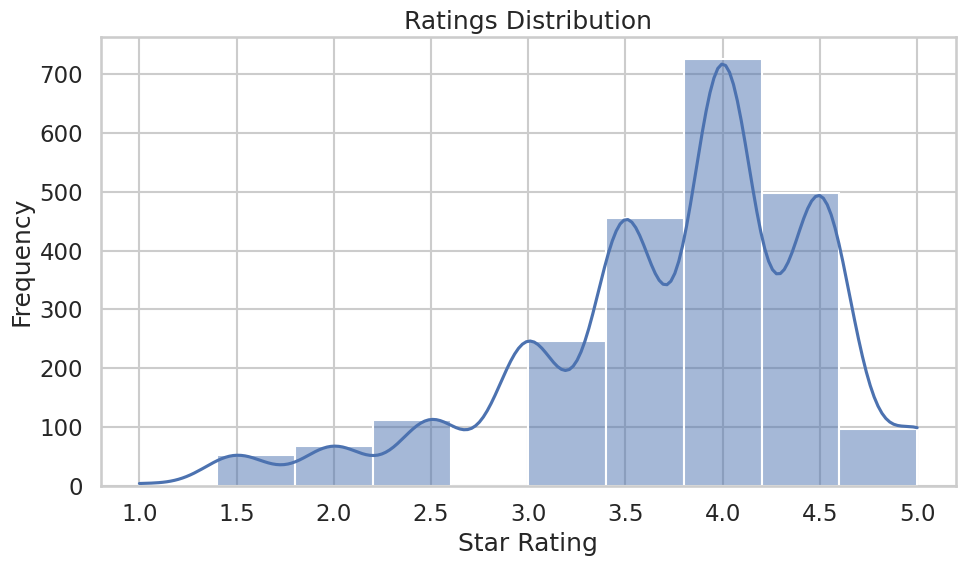

In [ ]:
# Create ratings distribution chart

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='stars', bins=10, kde=True)
plt.title('Ratings Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('ratings_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

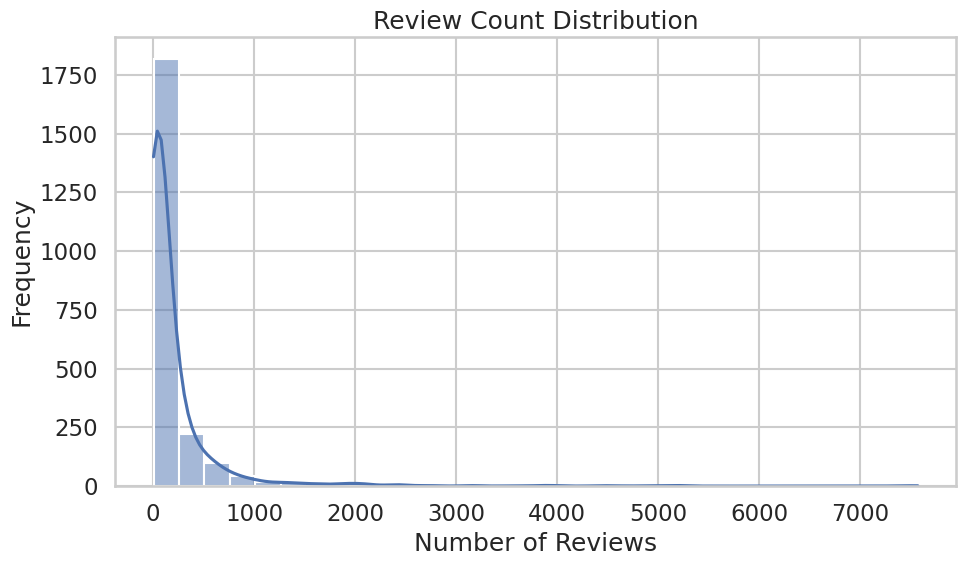

In [ ]:
# Create review count distribution chart

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review_count', bins=30, kde=True)
plt.title('Review Count Distribution')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('review_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

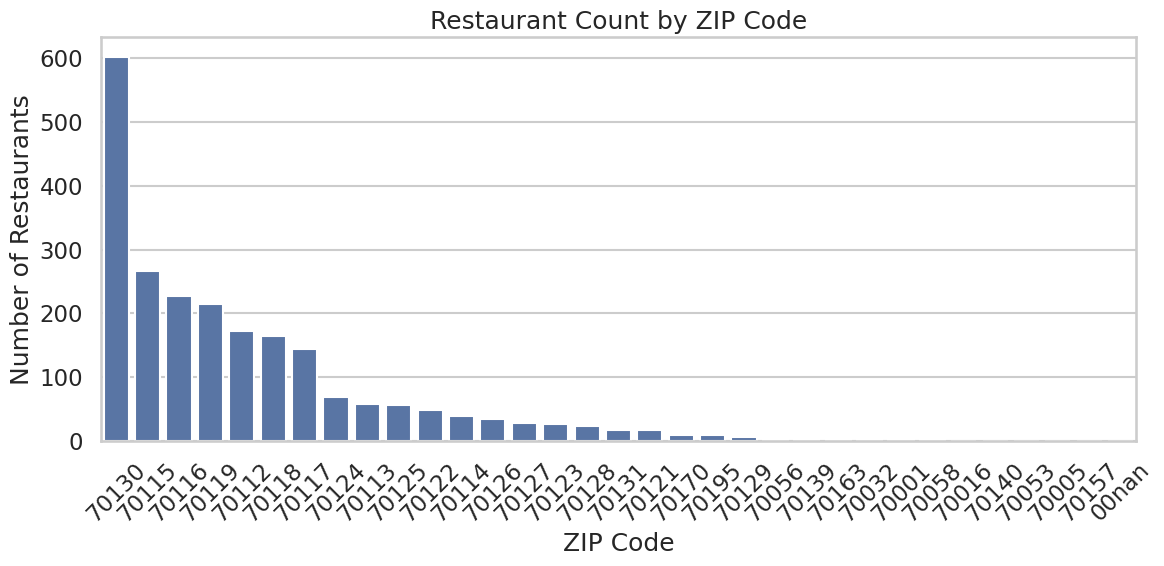

In [ ]:
# Create restaurant count by ZIP code chart (clean 5-digit ZIPs)

# Clean ZIP codes: remove decimals, keep 5 digits, handle missing
df['postal_code'] = df['postal_code'].astype(str).str.split('.').str[0].str.zfill(5)

zip_counts = df['postal_code'].value_counts().sort_values(ascending=False).reset_index()
zip_counts.columns = ['postal_code', 'restaurant_count']

plt.figure(figsize=(12, 6))
sns.barplot(data=zip_counts, x='postal_code', y='restaurant_count')
plt.title('Restaurant Count by ZIP Code')
plt.xlabel('ZIP Code')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('restaurant_count_by_zip.png', dpi=300, bbox_inches='tight')
plt.show()

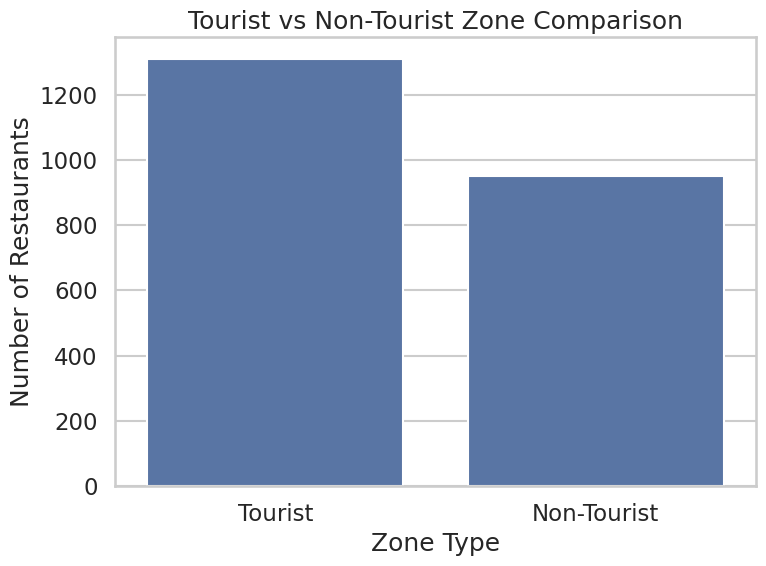

In [ ]:
# Create tourist vs non-tourist zone comparison chart

threshold = df['competition_density'].median()
df['zone_type'] = df['competition_density'].apply(lambda x: 'Tourist' if x >= threshold else 'Non-Tourist')

zone_counts = df['zone_type'].value_counts().reset_index()
zone_counts.columns = ['zone_type', 'restaurant_count']

plt.figure(figsize=(8, 6))
sns.barplot(data=zone_counts, x='zone_type', y='restaurant_count')
plt.title('Tourist vs Non-Tourist Zone Comparison')
plt.xlabel('Zone Type')
plt.ylabel('Number of Restaurants')
plt.tight_layout()

plt.savefig('tourist_vs_nontourist.png', dpi=300, bbox_inches='tight')
plt.show()

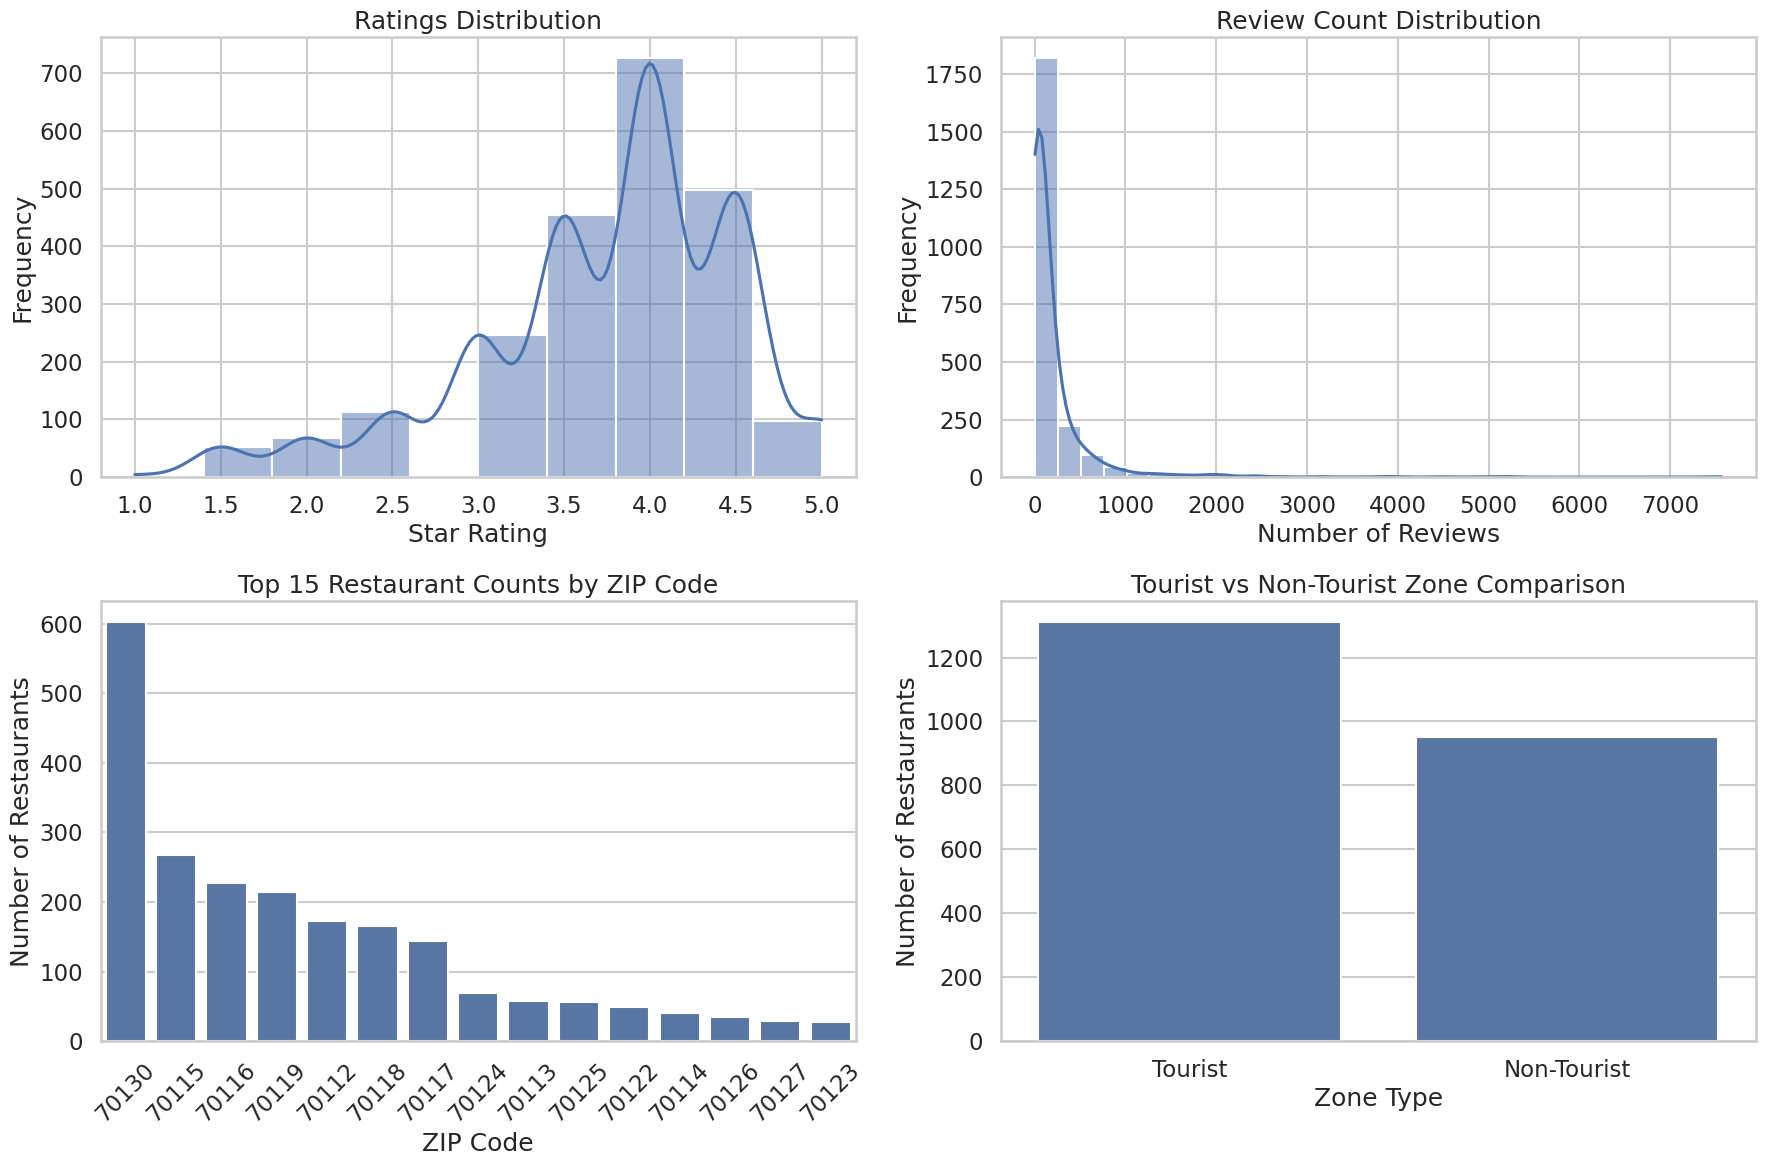

In [ ]:
# Create dashboard-style figure with all required charts

df['postal_code'] = df['postal_code'].astype(str).str.split('.').str[0].str.zfill(5)

threshold = df['competition_density'].median()
df['zone_type'] = df['competition_density'].apply(lambda x: 'Tourist' if x >= threshold else 'Non-Tourist')

zip_counts = df['postal_code'].value_counts().reset_index()
zip_counts.columns = ['postal_code', 'restaurant_count']
zip_counts = zip_counts.head(15)

zone_counts = df['zone_type'].value_counts().reset_index()
zone_counts.columns = ['zone_type', 'restaurant_count']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(data=df, x='stars', bins=10, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Ratings Distribution')
axes[0, 0].set_xlabel('Star Rating')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(data=df, x='review_count', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Review Count Distribution')
axes[0, 1].set_xlabel('Number of Reviews')
axes[0, 1].set_ylabel('Frequency')

sns.barplot(data=zip_counts, x='postal_code', y='restaurant_count', ax=axes[1, 0])
axes[1, 0].set_title('Top 15 Restaurant Counts by ZIP Code')
axes[1, 0].set_xlabel('ZIP Code')
axes[1, 0].set_ylabel('Number of Restaurants')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(data=zone_counts, x='zone_type', y='restaurant_count', ax=axes[1, 1])
axes[1, 1].set_title('Tourist vs Non-Tourist Zone Comparison')
axes[1, 1].set_xlabel('Zone Type')
axes[1, 1].set_ylabel('Number of Restaurants')

plt.tight_layout()
plt.savefig('restaurant_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

Visualizations Summary Points

*  Restaurant ratings are concentrated in the 3.5 to 4.5 star range, indicating generally strong customer satisfaction across the dataset. The limited spread suggests that most restaurants meet a consistent quality threshold, making it more difficult for individual businesses to differentiate purely on ratings alone.

*   Review counts are highly right-skewed, with a small subset of restaurants capturing a disproportionately large share of customer engagement. This suggests that visibility and popularity are not evenly distributed, and that certain restaurants benefit significantly from higher exposure and customer traffic.

*   High-impact locations, such as areas comparable to the French Quarter or other major tourist districts, play a critical role in restaurant popularity. Restaurants in these zones benefit from increased foot traffic, visitor spending, and repeat exposure. These factors all  contribute to higher review counts and overall visibility compared to restaurants in less trafficked areas.

*  The comparison between tourist and non-tourist zones reinforces that restaurants in high competition density areas are more prevalent and tend to achieve greater engagement, indicating that businesses are strategically locating in high-traffic environments despite increased competition.



